### Bibliothéque

In [171]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns


from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
import re

### Charger les donées :

In [131]:
my_data = pd.read_csv("extrait_produits.csv") 

### Renomage des colonnes : 

In [132]:
# Renommer les colonnes utiles
my_data = my_data.rename(columns={
    "ia_product": "interpretation_product",
    "conditioning_unit": "conditioning",
    "unit_price_without_tax": "price"
})

### 1. ANALYSE EXPLORATOIRE DES DONNÉES

#### Afficher les 5 premiére lignes :

In [133]:
my_data.head()

,id_operator,id_document,designation,item_code,interpretation_product,id_etablishment,conditioning,quantity,price,item_discount
0,47,36027,Oignon rge 50/70 5K c1 FR,106534,oignon rouge,264,KG,5.0,1.900,0.0
1,47,36027,Tom cer rde mixte 4K c2 REG,175595,tomate cerise rouge,264,KG,4.0,6.555,0.0
2,47,36027,HF basilic sac 100g KE,195823,basilic frais,264,SAC,6.0,1.900,0.0
3,47,36027,HF basilic sac 100g KE,195823,basilic frais,264,SAC,5.0,1.900,0.0
4,47,36027,Aubergine 300/400 HVE plt 5K B&E c1 REG°,244337,aubergine entiere,264,KG,5.0,1.600,0.0


#### Afficher les 5 derniére lignes :

In [134]:
my_data.tail()

,id_operator,id_document,designation,item_code,interpretation_product,id_etablishment,conditioning,quantity,price,item_discount
220490,138,103639,BROCHETTE BAMBOU GOLF 15CMX100,966055,brochette bambou golf,533,SHT,2.000,2.500,0.0
220491,138,103639,S COTE VB 420/480 G S/V X 10,492814,cote agneau carre,533,KG,4.472,15.090,0.0
220492,138,103639,CUISSE CANARD 350G S/V X2 FRANCE,30010,cuisse canard,533,SHT,4.000,6.950,0.0
220493,138,103639,E OLIVES NOIRES DENOYAUTEES 34/37 4/4X 6UNT PE...,879093,olive noir confite denoyaute,533,BTE,1.000,2.344,0.0
220494,138,103639,SAUCE BEARNAISE BOUTEILLE 920G GYMA,872188,sauce bearnaise,533,PCE,1.000,4.950,0.0


#### Afficher les valeurs manquantes :

In [135]:
print("valeurs manquantes")
print(my_data.isnull().sum())

valeurs manquantes
id_operator                   0
id_document                   0
designation                   0
item_code                 23183
interpretation_product    33846
id_etablishment               0
conditioning              96883
quantity                      0
price                         0
item_discount                 0
dtype: int64


#### Garder uniquement les lignes complètes sur les colonnes critiques


In [136]:
my_data = my_data.dropna(subset=["interpretation_product", "conditioning", "price"])

#### Statistiques descriptives

In [137]:
print("Statistiques de base sur les prix :")
my_data["price"].describe()

Statistiques de base sur les prix :


count    106267.000000
mean         32.391541
std        1296.648509
min       -5160.000000
25%           2.600000
50%           6.152000
75%          11.862000
max      239000.000000
Name: price, dtype: float64

#### Nombre de conditionnements différents par produit

In [138]:
condition_per_product = my_data.groupby("interpretation_product")["conditioning"].nunique()
print("Produits avec plusieurs conditionnements :")
condition_per_product[condition_per_product > 1].head()

Produits avec plusieurs conditionnements :


interpretation_product
400g base pain campagne      3
Perrier fines bulles 1L      2
abatilles petillante 1       5
abatilles petillante 50cl    2
abatilles plate 33cl         4
Name: conditioning, dtype: int64

#### Detection des valeurs abbérantes :

In [139]:
negative_price = my_data[my_data["price"] < 0]
very_hight_price = my_data[my_data["price"] > 1000]
print(f"Le nombre de valeurs price negatifs est de : {len(negative_price)}")
print(f"Le nombre de valeurs  price supérieur a 1000 € est de : {len(very_hight_price)}")

Le nombre de valeurs price negatifs est de : 57
Le nombre de valeurs  price supérieur a 1000 € est de : 273


Remarque : On sais que les produits alimentaire pour la restaurations ont généralement un priw unitaire < 1000€, sur la base de donnée quand on observes des prix supérieur a 1000 € cela nous permet de déduire que c'est peut etre du a une `Erreur de saisie`, une `Mauvaise unite de conditionnement` ou que le  `Prix cumulé pour plusieurs unités au lieu du prix d’une unité`.

In [140]:
print(my_data["price"].quantile([0.90, 0.95, 0.99]))


0.90     20.8882
0.95     39.3600
0.99    154.8000
Name: price, dtype: float64


Deduction et interprétation : 
- `90% des produit on un prix de <= 20.89 €`
- `95% des produit on un prix de <= 39.36 €`
- `99% des produit on un prix de <= 154.80 $`

Donc on peut prendre un seuil de 154 par exemple pour filtrer les données pour garder les 1% les plus chers qu sont  souvent anormaux ou exceptionnels.

#### Visualisation des donnée abbérante (Boxplot):

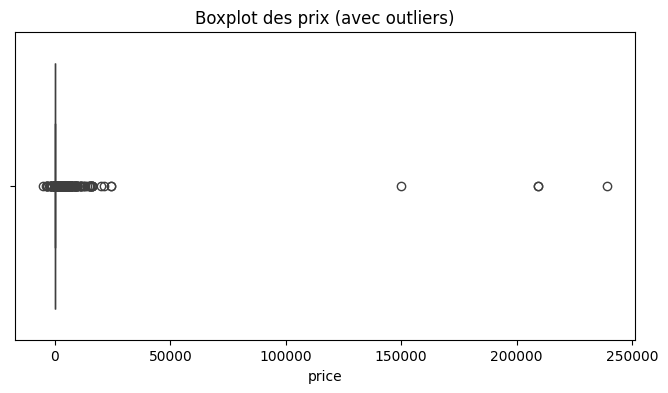

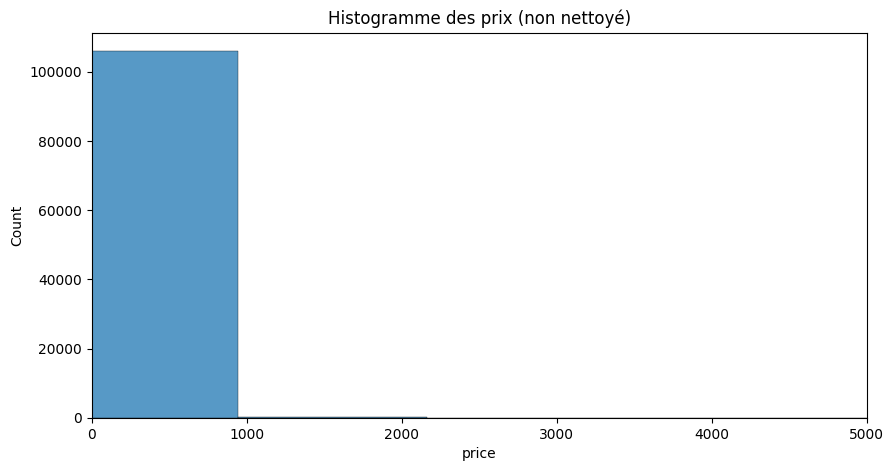

In [141]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=my_data["price"])
plt.title("Boxplot des prix (avec outliers)")
plt.show()

plt.figure(figsize=(10, 5))
sns.histplot(my_data["price"], bins=200)
plt.title("Histogramme des prix (non nettoyé)")
plt.xlim(0, 5000)
plt.show()

#### Suppression des valeurs abbérantes :

In [142]:
my_data_cleaned = my_data[(my_data["price"] > 0) & (my_data["price"] <= 150)]

In [143]:
len(my_data_cleaned)

104465

#### Visualisations :

##### Distribution des prix :

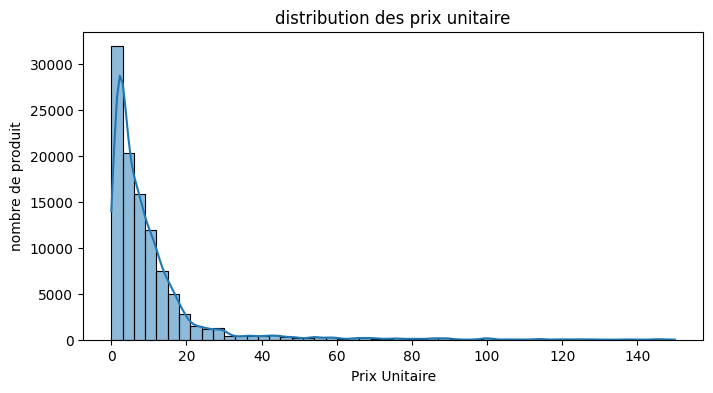

In [144]:
plt.figure(figsize=(8,4))
sns.histplot(my_data_cleaned["price"],bins=50, kde=True)
plt.title("distribution des prix unitaire")
plt.xlabel("Prix Unitaire")
plt.ylabel("nombre de produit")
plt.show()


### 2. METHODOLOGIE - ANALYSE DES VARIATIONS

#### Identifier les produits avec plusieurs conditionnements

In [147]:
multi_cond_prods = condition_per_product[condition_per_product > 1].index
multi_cond_data = my_data_cleaned[my_data_cleaned["interpretation_product"].isin(multi_cond_prods)]
multi_cond_data

,id_operator,id_document,designation,item_code,interpretation_product,id_etablishment,conditioning,quantity,price,item_discount
0,47,36027,Oignon rge 50/70 5K c1 FR,106534,oignon rouge,264,KG,5.000,1.900,0.0
1,47,36027,Tom cer rde mixte 4K c2 REG,175595,tomate cerise rouge,264,KG,4.000,6.555,0.0
2,47,36027,HF basilic sac 100g KE,195823,basilic frais,264,SAC,6.000,1.900,0.0
3,47,36027,HF basilic sac 100g KE,195823,basilic frais,264,SAC,5.000,1.900,0.0
4,47,36027,Aubergine 300/400 HVE plt 5K B&E c1 REG°,244337,aubergine entiere,264,KG,5.000,1.600,0.0
...,...,...,...,...,...,...,...,...,...,...
220490,138,103639,BROCHETTE BAMBOU GOLF 15CMX100,966055,brochette bambou golf,533,SHT,2.000,2.500,0.0
220491,138,103639,S COTE VB 420/480 G S/V X 10,492814,cote agneau carre,533,KG,4.472,15.090,0.0
220492,138,103639,CUISSE CANARD 350G S/V X2 FRANCE,30010,cuisse canard,533,SHT,4.000,6.950,0.0
220493,138,103639,E OLIVES NOIRES DENOYAUTEES 34/37 4/4X 6UNT PE...,879093,olive noir confite denoyaute,533,BTE,1.000,2.344,0.0


#### Moyenne des prix par produit et conditionnement

In [150]:
price_stats_by_product = multi_cond_data.groupby(
    ["interpretation_product", "conditioning"]
)["price"].agg(["count", "mean", "std"]).reset_index()

In [152]:
print("\nExemple de variation des prix pour un produit :")
top_product = multi_cond_data["interpretation_product"].value_counts().index[0]
price_stats_by_product[price_stats_by_product["interpretation_product"] == top_product]


Exemple de variation des prix pour un produit :


,interpretation_product,conditioning,count,mean,std
3870,jeune pousse roquette,BQT,28,1.199000,0.000000
3871,jeune pousse roquette,COL,1,2.400000,NaN
3872,jeune pousse roquette,K,1,11.140000,NaN
3873,jeune pousse roquette,KG,885,6.045037,0.913752
3874,jeune pousse roquette,SAC,276,2.999348,0.006462


#### Comparaison prix à conditionnement équivalent

In [156]:
# Filtrer les produit ayant plusieurs enregistrements pour un meme conditionnement 
same_conditioning_data = my_data_cleaned.groupby(
    ["interpretation_product", "conditioning"]
).filter(lambda x: len(x) > 1)

# Agréger les statistiques de variation de prix pour un conditionnement identique
price_variation_same_conditioning = same_conditioning_data.groupby(
    ["interpretation_product", "conditioning"]
)["price"].agg(["min", "max", "mean", "std"]).reset_index()


In [157]:
price_variation_same_conditioning.head(10)

,interpretation_product,conditioning,min,max,mean,std
0,1664 ivc 33cl,COL,1.2620,1.2620,1.262000,0.000000
1,400g base pain campagne,Kg,4.0700,4.0700,4.070000,0.000000
2,45 days organic pilsner fut,unit,36.0000,39.2100,37.605000,2.269813
3,7 crus brut champagne,KG,9.5500,11.8500,10.125000,1.064693
4,Rozes rouge tawny,BTL,6.5908,7.6729,7.023640,0.558794
5,abatilles bordelaise plate 1lt,COL,0.8350,0.8350,0.835000,0.000000
6,abatilles petillante 1,BT,0.7780,8.9040,1.983455,2.797796
7,abatilles petillante 1,COL,0.9660,0.9660,0.966000,0.000000
8,abatilles petillante 1,L,0.2535,1.0492,0.906756,0.257234
9,abatilles petillante 50cl,BL3,0.8825,0.8825,0.882500,0.000000


Remarque :
- Les lignes avec std = 0 le prix est constant pour ce produit + conditionnement (pas de variation).
- Les lignes avec un std > 0 → il y a variation de prix pour un même conditionnement, ce qui peut indiquer : des différences entre fournisseurs ou des remises, ou anomalies.

In [159]:
# Calcul du pourcentage de variation des prix
price_variation_same_conditioning["variation_pct"] = (
    (price_variation_same_conditioning["max"] - price_variation_same_conditioning["min"])
    / price_variation_same_conditioning["min"]
) * 100

# Filtrer les produits avec une variation > 20 %
variation_threshold = 20
high_variation_products = price_variation_same_conditioning[
    price_variation_same_conditioning["variation_pct"] > variation_threshold
]

# Afficher les 10 plus fortes variations au-dessus du seuil
print(high_variation_products.sort_values("variation_pct", ascending=False).head(10))


         interpretation_product conditioning     min       max        mean  \
4830  pochette frite carton 140          SHT  0.0010    5.3000    2.650500   
5878                    sel fin          SAC  0.2820   76.1000   59.556937   
3612              martini rosso          BTL  0.0405   10.8115   10.474719   
2387              frais de port           KG  0.0650   15.0000    7.532500   
3802             mini financier          PCE  0.3831   81.9500   41.166550   
6299             taxes diverses        UNITE  0.0300    5.2300    2.526000   
5096    produits gastronomiques           PC  0.5400   68.3000   34.420000   
4332       orange valencia late           KG  1.0500  100.7700    3.558770   
4153            oeuf frais gros            P  0.2200   19.5000    5.055000   
784           cannoli siciliani        Unite  1.6500  114.0000  112.323134   

            std  variation_pct  
4830   3.746959  529900.000000  
5878  31.763741   26885.815603  
3612   1.904028   26595.061728  
2387  10.

### 3. Clustering:

#### Préparation des données :

In [161]:
# Regrouper par produit + conditionnement pour obtenir un prix moyen
cluster_data = my_data_cleaned.groupby(["interpretation_product", "conditioning"]).agg({"price": "mean"}).reset_index()
cluster_data

,interpretation_product,conditioning,price
0,1664 ivc 33cl,COL,1.262
1,400g base pain campagne,KG,5.931
2,400g base pain campagne,Kg,4.070
3,400g base pain campagne,PAQUET,7.080
4,45 days organic pilsner fut,unit,37.605
...,...,...,...
10892,yaourt vanille,PC,0.490
10893,yuzu,CART,18.500
10894,yuzu,PCE,11.747
10895,zeste citron,KILO,9.590


Important : Avant d'aller plus loin, en doit convertir toutes les valeurs en KG en gramme

In [163]:
def convert_weight(cond):
    cond = cond.lower()
    match = re.search(r"\d+(?:[\.,]\d+)?", cond)
    if match:
        number = float(match.group().replace(",", "."))
        if "kg" in cond:
            return number * 1000  # convertir en grammes
        elif "g" in cond:
            return number
    return None  

In [165]:
cluster_data["weight_in_g"] = cluster_data["conditioning"].apply(lambda x: convert_weight(str(x)))
cluster_data.head()

,interpretation_product,conditioning,price,weight_in_g
0,1664 ivc 33cl,COL,1.262,NaN
1,400g base pain campagne,KG,5.931,NaN
2,400g base pain campagne,Kg,4.070,NaN
3,400g base pain campagne,PAQUET,7.080,NaN
4,45 days organic pilsner fut,unit,37.605,NaN


In [168]:
# Supprimer les lignes sans poids interprétable
cluster_data = cluster_data.dropna(subset=["weight_in_g"])
cluster_data.head()

,interpretation_product,conditioning,price,weight_in_g
137,amande decortique grise,CAR 10 KG,6.22,10000.0
138,amande decortique grise,CAR 10 KG,6.22,10000.0
143,amande effilee,CAR 5 KG,7.16,5000.0
144,amande effilee,CAR 5 KG,7.16,5000.0
166,amande poudre,CAR 10 KG,5.73,10000.0


#### Normalisation des données :

In [169]:
# On garde uniquement les colonnes utiles
X = cluster_data[["price", "weight_in_g"]]

In [174]:
# Standardiser les données 
scaler = StandardScaler()
normalized_data = scaler.fit_transform(X)

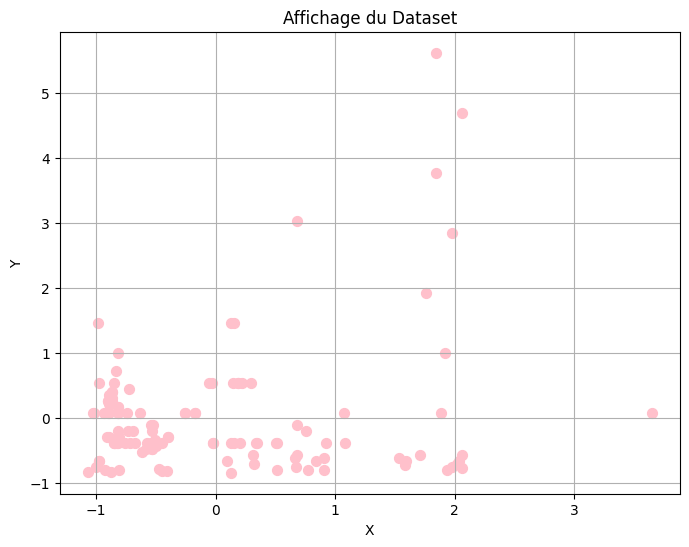

In [179]:
# Visualisation des donnée normaliser
plt.figure(figsize=(8,6))
plt.scatter(normalized_data[:,0],normalized_data[:,1],color="pink",s=50)
plt.title("Affichage du Dataset")
plt.xlabel("X")
plt.ylabel("Y")
plt.grid(True)
plt.show()

#### Clustering avec KMeans :

In [175]:
# Fonction pour determiner le nombre n_cluster idéale pour ce genre de probléme
def number_of_cluster(data):
    score_sil = []
    plage_cluster =range(2,10)
    for n in plage_cluster:
        km = KMeans(n_clusters=n,random_state=0)
        labels = km.fit_predict(data)
        score_sil.append(silhouette_score(data,labels))
    
    optimal_k = plage_cluster[np.argmax(score_sil)]
    return optimal_k

In [185]:
n = number_of_cluster(normalized_data)
kmeans = KMeans(n_clusters=n, random_state=0)
kmeans.fit(normalized_data)

# Prediction
kmeans_labels = kmeans.labels_
centroides = kmeans.cluster_centers_

print("le nombre de cluster utiliser est :",n)
print("Labels :", kmeans_labels)
print("Centres :", centroides)

le nombre de cluster utiliser est : 3
Labels : [0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 1 0 0 0 1 1 1 1 1 1 1 1 1 1 1 1 1 1 0 1 0 0 0 0 1 2 1 0 0 0 0 0 1 1 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 2 2 2 2 2 0 0 1 1 1 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0]
Centres : [[-0.53847766 -0.09037256]
 [ 1.30233267 -0.47721045]
 [ 1.69281063  3.6470435 ]]


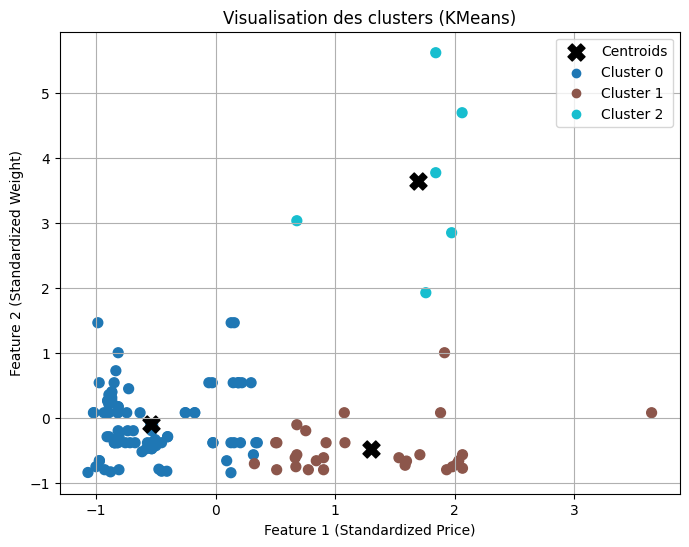


Résumé des clusters (valeurs originales) :
         price_original  weight_original
cluster                                 
0              3.980030      8203.359551
1             15.334373      4015.241379
2             17.742889     48666.666667


In [ ]:
# Visualisation des resultats

def visualise_cluster(data,labels):
  
    scatter = plt.scatter(data[:,0], data[:,1], c=labels, cmap="tab10", s=50)

    for label in np.unique(labels):
        plt.scatter([], [], color=scatter.cmap(scatter.norm(label)), label=f'Cluster {label}')

    plt.title("Visualisation des clusters (KMeans)")
    plt.xlabel("Feature 1")
    plt.ylabel("Feature 2")
    plt.legend()
    plt.grid(True)
    plt.show()
    
visualise_cluster(normalized_data,kmeans_labels)